# Trabajo Práctico N°4 de TPS: LDA, QDA y KNN

En este trabajo práctico se aborda el problema de reconocimiento de rostros a partir de imágenes.
Se utiliza el dataset Olivetti Faces y se implementan desde cero los algoritmos LDA, QDA y KNN
para identificar la identidad de una persona a partir de su fotografía.

En primer lugar, se importan las librerías que se utilizarán a lo largo del mismo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from sklearn.datasets import fetch_olivetti_faces
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

## Ítem A: Exploración de datos y split estratificado


En este inciso se realiza una primera exploración de la base de datos y se preparan los datos para los experimentos posteriores.
Se cargan las imágenes del dataset Olivetti Faces, se visualizan algunos ejemplos para entender su estructura y se construye
la partición de entrenamiento y testeo.


### Punto 1

Primero se comienza por cargar los datos desde sklearn si está disponible, y en caso contrario desde el archivo local `olivetti.npy`. Además, se extrae información básica del dataset para entender con qué se está trabajando antes de avanzar.

In [2]:
# --- PUNTO A.1: Cargar datos ---
if SKLEARN_AVAILABLE:
    dataset = fetch_olivetti_faces(shuffle=False)
    X = dataset.data        # shape: (400, 4096), píxeles aplanados
    y = dataset.target      # shape: (400,), etiquetas 0..39
    print("Datos cargados desde sklearn.")
else:
    data = np.load("../data/olivetti.npy", allow_pickle=True).item()
    X = data["data"]
    y = data["target"]
    print("Datos cargados desde olivetti.npy.")

# --- Exploración básica del dataset ---
n_imagenes      = X.shape[0]
n_pixeles       = X.shape[1]
lado_img        = int(np.sqrt(n_pixeles))   # 64
clases          = np.unique(y)
n_personas      = len(clases)
imgs_por_class  = np.array([np.sum(y == c) for c in clases])

print(f"\n{'='*45}")
print(f"  RESUMEN DEL DATASET OLIVETTI FACES")
print(f"{'='*45}")
print(f"  Total de imágenes        : {n_imagenes}")
print(f"  Número de personas       : {n_personas}")
print(f"  Imágenes por persona     : {imgs_por_class.min()} – {imgs_por_class.max()} (min–max)")
print(f"  Resolución de cada imagen: {lado_img} x {lado_img} px = {n_pixeles} features")
print(f"  Rango de valores de pixel: [{X.min():.3f}, {X.max():.3f}]")
print(f"  Tipo de dato             : {X.dtype}")
print(f"{'='*45}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Datos cargados desde sklearn.

  RESUMEN DEL DATASET OLIVETTI FACES
  Total de imágenes        : 400
  Número de personas       : 40
  Imágenes por persona     : 10 – 10 (min–max)
  Resolución de cada imagen: 64 x 64 px = 4096 features
  Rango de valores de pixel: [0.000, 1.000]
  Tipo de dato             : float32


Del resumen anterior se pueden observar varias cosas relevantes:

- **Dataset perfectamente balanceado**: las 40 clases tienen exactamente 10 imágenes cada una. Esto es ideal porque ninguna clase "pesa" más que otra (ya que tenemos la misma cantidad de info para cada una), por lo que no se necesitan técnicas de balanceo.
- **Alta dimensionalidad con pocas muestras**: un aspecto importante de este *dataset* es que cada imagen tiene muchas características
(muchos píxeles) en comparación con la cantidad de datos disponibles. Esto implica que
hay pocas muestras para estimar correctamente la varianza del modelo.
- **Píxeles normalizados en [0, 1]**: como se ve en el rango impreso, sklearn ya divide los valores originales (0–255) por 255 al cargar el dataset. No se requiere preprocesamiento adicional de escala.
- **Tipo `float32`**: ocupa la mitad de memoria que `float64`. No afecta la lógica pero puede generar pequeños errores numéricos en operaciones como inversión de matrices si $\lambda$ es muy chico.

Una vez realizado este análisis inicial y comprendida mejor la estructura del dataset,
se grafican algunas imágenes seleccionadas al azar con el objetivo de visualizar los datos.


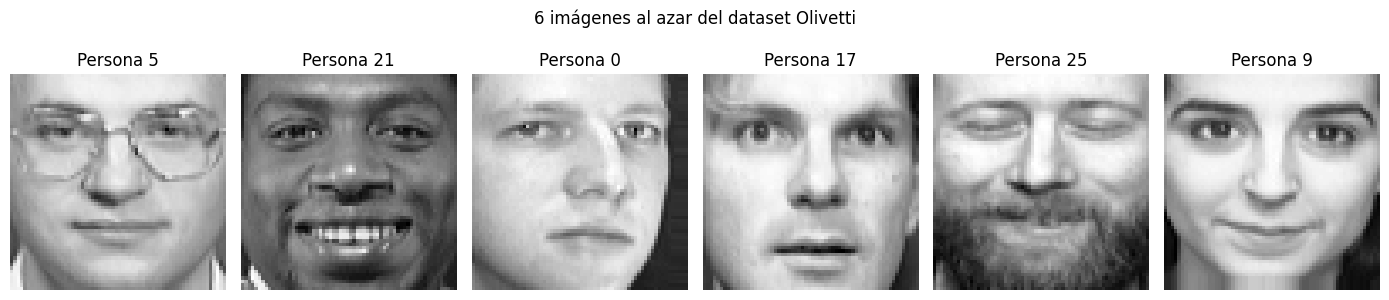

In [3]:
# Graficar 6 imágenes al azar
rng = np.random.default_rng()
indices = rng.choice(len(X), size=6, replace=False)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, idx in zip(axes, indices):
    ax.imshow(X[idx].reshape(64, 64), cmap="gray")
    ax.set_title(f"Persona {y[idx]}")
    ax.axis("off")
plt.suptitle("6 imágenes al azar del dataset Olivetti", y=1.02)
plt.tight_layout()
plt.show()

### Punto 2

Se separa la base de datos en entrenamiento (8 imágenes por persona) y testeo (2 imágenes por persona) de forma estratificada debido a:

- **Riesgo de clases vacías**: con solo 10 imágenes por persona, un split totalmente aleatorio podría dejar a alguien sin representación en test; o peor, con imágenes en test de alguien que el modelo nunca vio en entrenamiento.

- **La proporción entre clases no es algo que el modelo deba aprender**: si por azar la persona 3 termina con 9 imágenes en train y la persona 7 con solo 4, el modelo aprendería a "preferir" a la persona 3 simplemente por haberla visto más. Eso no refleja ninguna realidad del problema, es un artefacto del split. Como el dataset fue construido intencionalmente con 10 imágenes por persona, lo correcto es mantener esa uniformidad.

Por eso se garantiza que el split sea exactamente 8-2 para cada persona, no solo aproximadamente.

In [4]:
# --- PUNTO A.2: Split estratificado (2 imágenes por persona para test) ---
rng = np.random.default_rng(seed=0)

train_idx = []
test_idx  = []

for clase in np.unique(y):
    # índices de todas las imágenes de esta persona
    idx_clase = np.where(y == clase)[0]
    # elegir 2 al azar para test
    elegidos = rng.choice(idx_clase, size=2, replace=False)
    test_idx.extend(elegidos)
    # el resto va a train
    train_idx.extend([i for i in idx_clase if i not in elegidos])

train_idx = np.array(train_idx)
test_idx  = np.array(test_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"Entrenamiento: {X_train.shape[0]} imágenes  ({X_train.shape[0]//40} por persona)")
print(f"Testeo:        {X_test.shape[0]}  imágenes  ({X_test.shape[0]//40} por persona)")

Entrenamiento: 320 imágenes  (8 por persona)
Testeo:        80  imágenes  (2 por persona)


Un dato importante es que a diferencia de la celda de visualización, acá sí se usa una semilla fija (`seed=0`). El split train/test determina qué tan bien le va a cada modelo, así que tiene que ser siempre el mismo: si cambiara en cada ejecución, los resultados de LDA, QDA y KNN no serían comparables entre sí, y tampoco podrían reproducirse por otra persona que corra el notebook.

## Ítem B: Linear Discriminant Analysis (LDA)

LDA es un clasificador generativo: en lugar de aprender directamente "¿esta imagen pertenece a la persona $k$?", aprende cómo son las imágenes de cada persona y después usa Bayes para inferir la identidad.



### Punto 1



#### ¿Qué aprende en entrenamiento?

Dado que tenemos 8 fotos de entrenamiento de cada persona, el LDA aprende dos cosas:

 **El rostro promedio de cada persona** $\hat{\mu}_k$

 Simplemente promedia las 8 imágenes. Es como una "foto número 9" borrosa que captura cómo es esa persona en general — la forma de la cara, la posición de los ojos, etc.

$$\hat{\mu}_k = \frac{1}{|D_k|}\sum_{x \in D_k} x$$

Donde $D_k$ es el conjunto de imágenes de entrenamiento que pertenecen a la persona $k$, como hay 8 fotos, $|D_k|=8$.

Cada $x$ es un vector de 4096 píxeles, la suma se hace píxel a píxel: el píxel 1 de las 8 fotos se promedia, el píxel 2 de las 8 fotos se promedia, y así. El resultado es una imagen donde cada píxel vale el promedio de ese mismo píxel en las 8 fotos de entrenamiento de esa persona.

**¿Por qué el promedio?** Si se asume que las fotos siguen una gaussiana centrada en $\mu_k$, el valor de $\mu_k$ que maximiza la probabilidad de haber observado esas 8 fotos (MLE) es siempre el promedio muestral — es el centro de la campana que mejor "cubre" los datos.

**La variabilidad típica de las fotos** $\hat{\Sigma}$

Además del promedio de cada persona, LDA necesita una forma de describir cómo suelen variar las fotos en general.
La idea no es capturar qué hace único a cada individuo, sino entender qué cambios son habituales en una imagen de rostro.

Para eso, primero se analiza cada persona por separado:
se mide cuánto varían sus propias fotos respecto a su propio promedio
(Juan con Juan, Pedro con Pedro, nunca entre personas distintas).
Esto da lugar a una matriz de covarianza por persona, $\hat{\Sigma}_k$,
que resume cambios típicos como iluminación, expresión o pequeñas variaciones de pose
dentro de esa misma persona.

Luego, todas estas matrices se combinan en una única matriz $\hat{\Sigma}$.
Como en este dataset todas las personas tienen la misma cantidad de fotos,
esta combinación es simplemente un promedio entre las covarianzas individuales.
De esta manera se obtiene una descripción global de la variabilidad típica de las imágenes.

La idea clave es que los factores que aparecen en todas las personas
(por ejemplo luz o expresión facial)
están presentes en cada $\hat{\Sigma}_k$ y, al promediarlas,
no se cancelan, sino que quedan reflejados en la matriz final.
En cambio, variaciones muy particulares de un solo individuo
tienden a diluirse y no dominan el modelo.

Formalmente, estas matrices se calculan como:

$$
\hat{\Sigma} = \frac{1}{n-K}\sum_{k=1}^{K}(|D_k|-1)\hat{\Sigma}_k,
\qquad
\hat{\Sigma}_k = \frac{1}{|D_k|-1}\sum_{x \in D_k}(x-\hat{\mu}_k)(x-\hat{\mu}_k)^T
$$

El supuesto clave de LDA es que todas las personas comparten la misma matriz de covarianza.
Esto implica que las diferencias entre clases se explican únicamente
a partir de sus promedios y no por la forma en la que varían sus imágenes.

Puede pensarse a LDA como un amplificador diferencial:
la matriz $\hat{\Sigma}$ modela la variación común presente en todas las caras
(lo que no ayuda a distinguir personas)
y el algoritmo la utiliza para atenuar ese “modo común”.
De esta forma, se resaltan únicamente las diferencias reales entre los promedios de cada persona,
que son las que permiten la clasificación.

Como consecuencia directa de este supuesto,
las fronteras de decisión entre clases resultan ser rectas (lineales).


---

#### ¿Por qué las fronteras son lineales? Derivación paso a paso

**Paso 1 — Aplicar Bayes**: queremos encontrar la persona más probable dada una imagen $x$:

$$P(k|x) \propto P(x|k) \cdot \underbrace{P(k)}_{c_k = \frac{8}{320} = \frac{1}{40}}$$

Donde $P(x|k)$ es ¿qué tan típica es $x$  para la persona $k$?

**Paso 2 — Asumir gaussiana**: las imágenes de cada persona se distribuyen como $x|Y=k \sim \mathcal{N}(\mu_k, \Sigma)$:

$$P(x|k) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}} \exp\!\left(-\frac{1}{2}(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)\right)$$

**Paso 3 — Tomar logaritmo**: maximizar $P(k|x)$ es equivalente a maximizar su logaritmo:

$$\log P(k|x) \propto \log(c_k) - \frac{1}{2}(x-\mu_k)^T\Sigma^{-1}(x-\mu_k) - \underbrace{\frac{1}{2}\log|\Sigma|}_{\text{igual para todas las clases} \Rightarrow \text{se cancela}}$$

**Paso 4 — Expandir el producto cuadrático**:

$$(x-\mu_k)^T\Sigma^{-1}(x-\mu_k) = \underbrace{x^T\Sigma^{-1}x}_{\text{no depende de }k} - 2x^T\Sigma^{-1}\mu_k + \mu_k^T\Sigma^{-1}\mu_k$$

**Paso 5 — Cancelar lo que no depende de** $k$: el término $x^T\Sigma^{-1}x$ es el mismo para todas las clases, entonces no afecta cuál es la mayor. Se elimina.

**Resultado — la función discriminante lineal**:

$$\boxed{\tilde{\delta}_k(x) = x^T\tilde{\Sigma}^{-1}\mu_k + \log(c_k) - \frac{1}{2}\mu_k^T\tilde{\Sigma}^{-1}\mu_k}$$

- $x^T\tilde{\Sigma}^{-1}\mu_k$: similitud entre la imagen $x$ y el rostro promedio de la persona $k$, ponderada por $\tilde{\Sigma}^{-1}$ (los píxeles que varían poco entre fotos pesan más, porque son más informativos).
- $\log(c_k)$: el prior (acá igual para todos: $\log(1/40)$, así que no distingue entre clases).
- $-\frac{1}{2}\mu_k^T\tilde{\Sigma}^{-1}\mu_k$: constante de normalización por clase.

Es **lineal en** $x$ → las fronteras de decisión son hiperplanos. De ahí el nombre LDA.

Además, si comparamos dos clases Juan y Pedro, el modelo elige Juan cuando $\tilde{\delta}_{Juan} > \tilde{\delta}_{Pedro}$, es decir cuando:

$$x^T\tilde{\Sigma}^{-1}(\mu_{Juan} - \mu_{Pedro}) > \text{constante}$$

El término $(\mu_{Juan} - \mu_{Pedro})$ es exactamente la diferencia entre rostros — la información de "qué tan distintas son las personas entre sí" ya está implícita en la comparación.

---

La predicción **soft** (`predict_proba`) aplica softmax sobre los 40 puntajes $\tilde{\delta}_k(x)$ para obtener probabilidades. La predicción **hard** (`predict`) devuelve directamente la clase ganadora.



#### Implementación de la clase LDA
Se implementa la clase `LDA`. El hiperparámetro $\lambda$ controla la regularización de la covarianza. Se usa `float64` internamente para evitar errores numéricos en la inversión de la matriz.

In [5]:
class LDA:

    def __init__(self, lam=1e-2):
        """
        lam: factor de regularización λ para Σ̃ = Σ + λI.
             Necesario porque Σ es singular (p >> n).
        """
        self.lam = lam

    def fit(self, X, y):
        X = X.astype(np.float64)
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        n, d = X.shape

        self.priors_ = np.zeros(K)
        self.means_  = np.zeros((K, d))
        Sigma = np.zeros((d, d))

        for i, k in enumerate(self.classes_):
            Xk = X[y == k]
            nk = len(Xk)
            self.priors_[i] = nk / n
            self.means_[i]  = Xk.mean(axis=0)
            diff = Xk - self.means_[i]           # (nk, d)
            Sigma += diff.T @ diff                # acumula (nk-1)*Σ_k

        # Covarianza pooled insesgada: Σ = 1/(n-K) * Σ_k (|Dk|-1)*Σ_k
        Sigma /= (n - K)

        # Regularización: Σ̃ = Σ + λI  (hace Σ invertible)
        self.Sigma_reg_ = Sigma + self.lam * np.eye(d)
        self.Sigma_inv_ = np.linalg.inv(self.Sigma_reg_)

        # Precomputar términos de la función discriminante por clase:
        # δ̃_k(x) = x^T Σ⁻¹ μ_k  +  log(c_k) - 0.5 * μ_k^T Σ⁻¹ μ_k
        #           ↑ término lineal  ↑ bias (constante por clase)
        self.W_    = self.means_ @ self.Sigma_inv_          # (K, d)
        self.bias_ = np.array([
            np.log(self.priors_[i]) - 0.5 * self.means_[i] @ self.Sigma_inv_ @ self.means_[i]
            for i in range(K)
        ])
        return self

    def predict_proba(self, X):
        """Predicción soft: probabilidad posterior de cada clase via softmax."""
        X = X.astype(np.float64)
        delta = X @ self.W_.T + self.bias_          # (n_samples, K)
        # Softmax numéricamente estable
        delta -= delta.max(axis=1, keepdims=True)
        exp_d = np.exp(delta)
        return exp_d / exp_d.sum(axis=1, keepdims=True)

    def predict(self, X):
        """Predicción hard: clase con mayor función discriminante."""
        X = X.astype(np.float64)
        delta = X @ self.W_.T + self.bias_
        return self.classes_[np.argmax(delta, axis=1)]

    def accuracy(self, X, y):
        """Proporción de predicciones correctas."""
        return np.mean(self.predict(X) == y)

    def sampling(self, n_samples=1):
        """
        Simula muestras sintéticas del modelo generativo.
        Para cada muestra: elige una clase k según c_k, luego samplea x ~ N(μ_k, Σ̃).
        """
        rng = np.random.default_rng()
        L = np.linalg.cholesky(self.Sigma_reg_)    # Σ̃ = L @ L^T
        d = self.means_.shape[1]
        samples, labels = [], []
        for _ in range(n_samples):
            k = rng.choice(len(self.classes_), p=self.priors_)
            z = rng.standard_normal(d)
            x = self.means_[k] + L @ z             # x ~ N(μ_k, Σ̃)
            samples.append(x)
            labels.append(self.classes_[k])
        return np.array(samples), np.array(labels)

#### Regularización de la matriz de covarianza

Para clasificar una imagen, LDA necesita calcular la inversa de la matriz de covarianza.
En la práctica, se trabaja con la matriz regularizada $\tilde{\Sigma}^{-1}$.
El problema es que, en este *dataset*, las imágenes tienen una dimensionalidad muy alta
($p = 4096$ píxeles), mientras que la cantidad de muestras de entrenamiento es mucho menor
($n = 320$ imágenes).

Esto implica que los datos no ocupan todo el espacio de dimensión 4096, sino que viven en
un subespacio de dimensión mucho menor (a lo sumo $n-1$). Como consecuencia, la matriz de
covarianza estimada $\hat{\Sigma}$ no puede tener rango completo: existen muchas direcciones
del espacio donde no hay variación observada. En términos matemáticos, esto hace que
$\hat{\Sigma}$ sea singular (su determinante es cero) y, por lo tanto, no invertible.

Para resolver este problema se introduce la regularización. En lugar de invertir
directamente $\hat{\Sigma}$, se define una matriz de covarianza regularizada:

$$
\tilde{\Sigma} = \hat{\Sigma} + \lambda I
$$

Sumar $\lambda I$ significa agregar $\lambda$ a cada elemento de la diagonal de la matriz.
Dado que la diagonal de la matriz de covarianza representa la varianza de cada píxel,
esta operación puede interpretarse como asumir que ninguna dirección del espacio tiene
varianza exactamente cero, incluso aquellas donde los datos no aportan información suficiente.
En otras palabras, se impone una varianza mínima $\lambda$ en todas las direcciones.

Esto tiene un efecto geométrico claro: se evita asignar pesos infinitos a direcciones mal
estimadas al calcular la inversa de la covarianza. Sin regularización, pequeñas fluctuaciones
numéricas o ruido en direcciones poco observadas podrían ser amplificadas de manera extrema,
volviendo al clasificador inestable. Con regularización, estas direcciones siguen teniendo
peso, pero de forma acotada y controlada.

Formalmente, la regularización garantiza que la matriz sea invertible:

$$
\tilde{\Sigma} = \hat{\Sigma} + \lambda I
\quad \Longrightarrow \quad
\tilde{\Sigma}^{-1} \text{ existe siempre que } \lambda > 0
$$

El rol de $\lambda$ es análogo al de la regularización utilizada en regresión polinómica:
no elimina direcciones del espacio, sino que evita confiar ciegamente en estructuras mal
estimadas debido a la falta de datos. Valores pequeños de $\lambda$ estabilizan la inversión
sin distorsionar significativamente la covarianza observada.


Es importante notar que, aunque para direcciones regularizadas la inversa de la varianza
pueda tomar valores grandes cuando $\lambda$ es pequeño, esto no implica necesariamente
que dichas direcciones dominen la decisión. Para que una dirección influya en la
clasificación, no solo debe tener un peso grande en $\tilde{\Sigma}^{-1}$, sino que
también debe existir una diferencia significativa entre las clases al proyectar los datos
en esa dirección. En las direcciones donde la varianza es casi nula, los datos y los
promedios de las clases apenas varían, por lo que su contribución efectiva al criterio de
clasificación es muy baja. En teoría, podría ser problemático el caso de una dirección con
varianza muy pequeña pero con grandes diferencias entre clases; sin embargo, este escenario
es poco habitual en la práctica, ya que una diferencia discriminante fuerte suele venir
acompañada de variación observable en los datos. La regularización permite entonces limitar
la influencia de direcciones mal estimadas sin eliminar información relevante.
x

El valor $\lambda = 10^{-2}$ es una elección arbitraria inicial — simplemente un número chico que permite partir y ver cómo funciona el modelo. En QDA se analizará más formalmente cómo elegir $\lambda$ antes de entrenar.

### Puntos 2 y 3

Se entrena el LDA con los datos de entrenamiento y se evalúa sobre el conjunto de testeo.

In [6]:
# --- PUNTO B.2: Entrenar LDA ---
lda = LDA(lam=1e-2)
lda.fit(X_train, y_train)
print("LDA entrenado.")

# --- PUNTO B.3: Accuracy de testeo ---
acc_test  = lda.accuracy(X_test,  y_test)
acc_train = lda.accuracy(X_train, y_train)
print(f"Accuracy train : {acc_train:.2%}")
print(f"Accuracy test  : {acc_test:.2%}")

LDA entrenado.
Accuracy train : 100.00%
Accuracy test  : 100.00%


Resultó llamativo obtener un accuracy del 100% tanto en el conjunto de entrenamiento
como en el de testeo. Ante este resultado, se decidió analizar con mayor detalle el
comportamiento del modelo, variando el valor del parámetro de regularización $\lambda$
en el rango de $10^{-3}$ a $1$, y repitiendo los experimentos con distintas semillas
aleatorias. El objetivo de este análisis es verificar que el buen desempeño observado
no se deba a una configuración particular de los datos o a un efecto fortuito del split,
sino a un funcionamiento consistente del clasificador.

In [7]:
# --- Verificación: distintas semillas y distintos λ ---
seeds  = [0, 1, 2, 3, 4]
lambdas = [1e-3, 1e-2, 1e-1, 1.0]

print("LDA:")
print(f"{'seed':>5}  {'λ':>8}  {'train':>8}  {'test':>8}")
print("-" * 38)
for s in seeds:
    # split con esta semilla
    rng_s = np.random.default_rng(seed=s)
    tr_idx, te_idx = [], []
    for clase in np.unique(y):
        idx_c = np.where(y == clase)[0]
        eleg  = rng_s.choice(idx_c, size=2, replace=False)
        te_idx.extend(eleg)
        tr_idx.extend([i for i in idx_c if i not in eleg])
    Xtr, ytr = X[np.array(tr_idx)], y[np.array(tr_idx)]
    Xte, yte = X[np.array(te_idx)],  y[np.array(te_idx)]

    for lam in lambdas:
        m = LDA(lam=lam).fit(Xtr, ytr)
        print(f"{s:>5}  {lam:>8.0e}  {m.accuracy(Xtr,ytr):>7.1%}  {m.accuracy(Xte,yte):>7.1%}")

LDA:
 seed         λ     train      test
--------------------------------------
    0     1e-03   100.0%   100.0%
    0     1e-02   100.0%   100.0%
    0     1e-01   100.0%   100.0%
    0     1e+00    99.1%    97.5%
    1     1e-03   100.0%    98.8%
    1     1e-02   100.0%    98.8%
    1     1e-01   100.0%    98.8%
    1     1e+00    99.7%    97.5%
    2     1e-03   100.0%    96.2%
    2     1e-02   100.0%    97.5%
    2     1e-01   100.0%    97.5%
    2     1e+00   100.0%    95.0%
    3     1e-03   100.0%    97.5%
    3     1e-02   100.0%    98.8%
    3     1e-01   100.0%    98.8%
    3     1e+00   100.0%    97.5%
    4     1e-03   100.0%    96.2%
    4     1e-02   100.0%    96.2%
    4     1e-01   100.0%    97.5%
    4     1e+00   100.0%    92.5%


Los resultados de la tabla anterior tienen mucho sentido y se pueden explicar en tres observaciones:

**1. Train = 100% casi siempre**

Con $\lambda$ pequeño, LDA perfora perfectamente el conjunto de entrenamiento. Esto ocurre porque estamos en el régimen $p \gg n$ (4096 features, 320 muestras): en ese espacio de altísima dimensión los datos de cada persona están muy separados entre sí, y además los promedios $\hat{\mu}_k$ se calcularon
con esas mismas fotos, así que cada imagen queda cerca de su propio representante por construcción. Clasificar correctamente los datos con los que uno mismo aprendió es casi obligatorio.

**2. Test ≈ 95–100%: una accuracy sorprendentemente alta**

El dataset Olivetti fue diseñado en condiciones controladas: fondo uniforme, buena iluminación, poses similares. Las diferencias entre personas (estructura ósea, forma de la cara) son grandes y sistemáticas, mientras que las diferencias dentro de una misma persona (expresión, leve ángulo) son pequeñas. Con 8 fotos de entrenamiento el promedio $\hat{\mu}_k$ ya captura muy bien la identidad de cada persona, y eso generaliza bien a las 2 fotos de test.

Una forma de ver esto es mirar los rostros promedio graficados a continuación. Aunque son imágenes borrosas (son el promedio de 8 fotos), las diferencias entre personas son perfectamente visibles a simple vista: pelo largo vs. corto, anteojos o no, forma de la cara, etc. Si el ojo humano puede distinguirlos sin dificultad, LDA (que hace exactamente esa comparación de forma matemática) también puede. La alta accuracy no es un accidente: el problema tiene una señal discriminante muy clara.

**3. λ grande → peor performance**

Cuando $\lambda$ es grande, la covarianza regularizada se aproxima a una esfera:

$$\tilde{\Sigma} \approx \lambda I \quad \Rightarrow \quad \tilde{\Sigma}^{-1} \approx \frac{1}{\lambda} I$$

En ese caso, el término $x^T \tilde{\Sigma}^{-1} \mu_k$ se convierte en $\frac{1}{\lambda} x^T \mu_k$: todos los píxeles reciben el mismo peso. Se pierde la capacidad de ponderar más los píxeles informativos (los estables entre fotos) y menos los ruidosos (los que cambian con la expresión o la luz). El modelo ignora la estructura de varianza del dataset y su performance cae.

En síntesis, con $\lambda$ chico → $\tilde{\Sigma}^{-1}$ respeta la estructura de varianza de los datos → distingue bien qué píxeles son informativos → mayor accuracy. MIentras que con $\lambda$ grande → todo se aplana → se pierde discriminación.

Luego de analizar el comportamiento del modelo para distintos valores de $\lambda$,
se decidió continuar con $\lambda = 10^{-2}$, ya que presenta un buen compromiso entre
estabilidad numérica y desempeño, sin incurrir en un costo computacional elevado.

#### Las "fotos número 9": los rostros promedio aprendidos por LDA

Es posible visualizar directamente qué aprendió el modelo durante el entrenamiento a
través de los vectores $\hat{\mu}_k$ asociados a cada persona. Estos vectores corresponden
al promedio de sus 8 imágenes de entrenamiento y funcionan como la representación que LDA
utiliza para caracterizar a cada individuo.



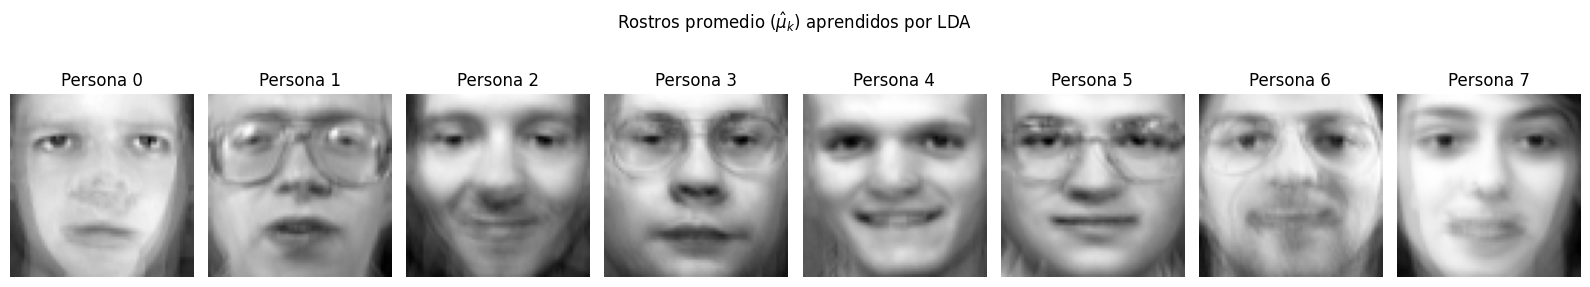

In [8]:
# Mostrar las "fotos 9": rostro promedio de las primeras 8 personas
n_mostrar = 8
fig, axes = plt.subplots(1, n_mostrar, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(lda.means_[i].reshape(64, 64), cmap="gray")
    ax.set_title(f"Persona {i}")
    ax.axis("off")
plt.suptitle("Rostros promedio ($\\hat{\\mu}_k$) aprendidos por LDA", y=1.02)
plt.tight_layout()
plt.show()

#### La varianza compartida

**La diagonal de $\hat{\Sigma}$: varianza píxel a píxel**

La matriz $\hat{\Sigma}$ tiene dimensión $4096 \times 4096$, pero su diagonal es simplemente un vector de 4096 números: el elemento $\hat{\Sigma}_{ii}$ indica cuánto varía el píxel $i$ a lo largo de todo el dataset de entrenamiento (midiendo las desviaciones respecto a los promedios de cada persona). Si ese número es alto, ese píxel cambia mucho entre fotos distintas. Si es bajo, ese píxel es prácticamente igual en todas las imágenes.

Al reshapear ese vector a $64 \times 64$ se obtiene el mapa de varianza: una imagen donde la intensidad de cada punto indica qué tan variable es ese píxel en el dataset.

El mapa se intepreta de la siguiente manera:

- **Zonas brillantes (alta varianza)**: son píxeles que cambian mucho. Típicamente corresponden al fondo, al pelo, y a zonas con variaciones de iluminación. Estas regiones aportan poca información para identificar a alguien, porque varían incluso entre fotos de la misma persona.
- **Zonas oscuras (baja varianza)**: son píxeles consistentes. Corresponden a la estructura ósea de la cara — la posición de los ojos, la nariz, los pómulos — que prácticamente no cambia entre fotos de una misma persona ni entre personas bajo las mismas condiciones. Estas son las zonas realmente discriminantes.

**Por qué $\tilde{\Sigma}^{-1}$ es la clave**

Cuando LDA calcula el puntaje de la clase $k$ para una imagen $x$:

$$\tilde{\delta}_k(x) = x^T \tilde{\Sigma}^{-1} \mu_k + \text{constante}$$

La matriz $\tilde{\Sigma}^{-1}$ actúa como un sistema de pesos: da más importancia a los píxeles de baja varianza y menos a los de alta varianza. Intuitivamente, se le está diciendo al clasificador que no se fije tanto en el fondo o en si la foto tiene más o menos luz, sino que es más importante la estructura de la cara, que es lo que realmente identifica a una persona.

Sin esta ponderación (es decir, si se usara $\tilde{\Sigma}^{-1} \approx \frac{1}{\lambda}I$ como ocurre con $\lambda$ grande), todos los píxeles tendrían el mismo peso y el clasificador trataría el ruido de iluminación con la misma importancia que la forma de los ojos — de ahí la caída de accuracy observada en la tabla anterior.

**El rostro promedio global**

Junto al mapa de varianza, se grafica también $\bar{\mu} = \frac{1}{K}\sum_{k=1}^K \hat{\mu}_k$: el promedio de todos los promedios. Es el "rostro genérico" del dataset — lo que tienen en común todas las personas. LDA no lo usa explícitamente para clasificar, pero es útil para entender qué parte de la información es compartida (y por ende no discriminante) y qué parte es propia de cada individuo.


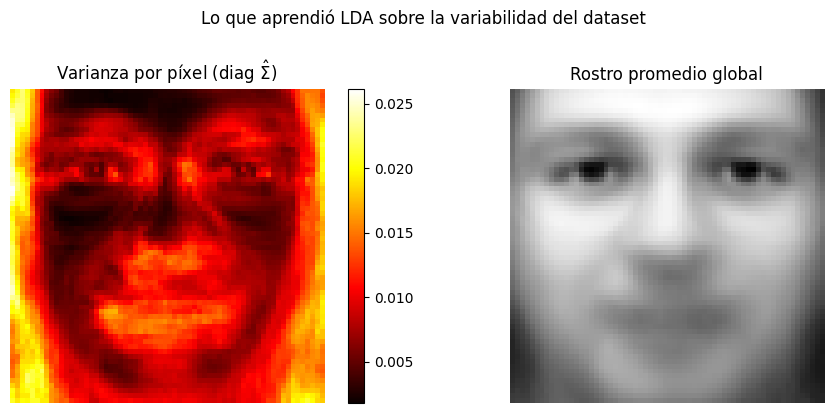

In [9]:
# La diagonal de Σ = varianza de cada píxel en el dataset
varianza_pixeles = np.diag(lda.Sigma_reg_ - lda.lam * np.eye(lda.Sigma_reg_.shape[0]))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Mapa de varianza
im = axes[0].imshow(varianza_pixeles.reshape(64, 64), cmap="hot")
axes[0].set_title("Varianza por píxel (diag $\\hat{\\Sigma}$)")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0])

# Foto promedio global (promedio de todos los μ_k)
media_global = lda.means_.mean(axis=0)
axes[1].imshow(media_global.reshape(64, 64), cmap="gray")
axes[1].set_title("Rostro promedio global")
axes[1].axis("off")

plt.suptitle("Lo que aprendió LDA sobre la variabilidad del dataset", y=1.02)
plt.tight_layout()
plt.show()

### Punto 4

Además de clasificar, LDA es un modelo generativo, lo que significa que aprende una
distribución probabilística para cada persona y permite generar nuevas imágenes que el
modelo considera plausibles. En particular, las muestras sintéticas se obtienen partiendo
del promedio $\hat{\mu}_k$ de una persona y agregando variación aleatoria según la
covarianza compartida $\tilde{\Sigma}$.

Estas imágenes sintéticas pueden interpretarse como posibles nuevas fotos de esa persona.
Compararlas con los promedios y con imágenes reales de entrenamiento permite evaluar si el
modelo capturó variaciones razonables o si, por el contrario, está generando ruido sin
estructura, lo cual sirve como una forma cualitativa de validar el modelo aprendido.

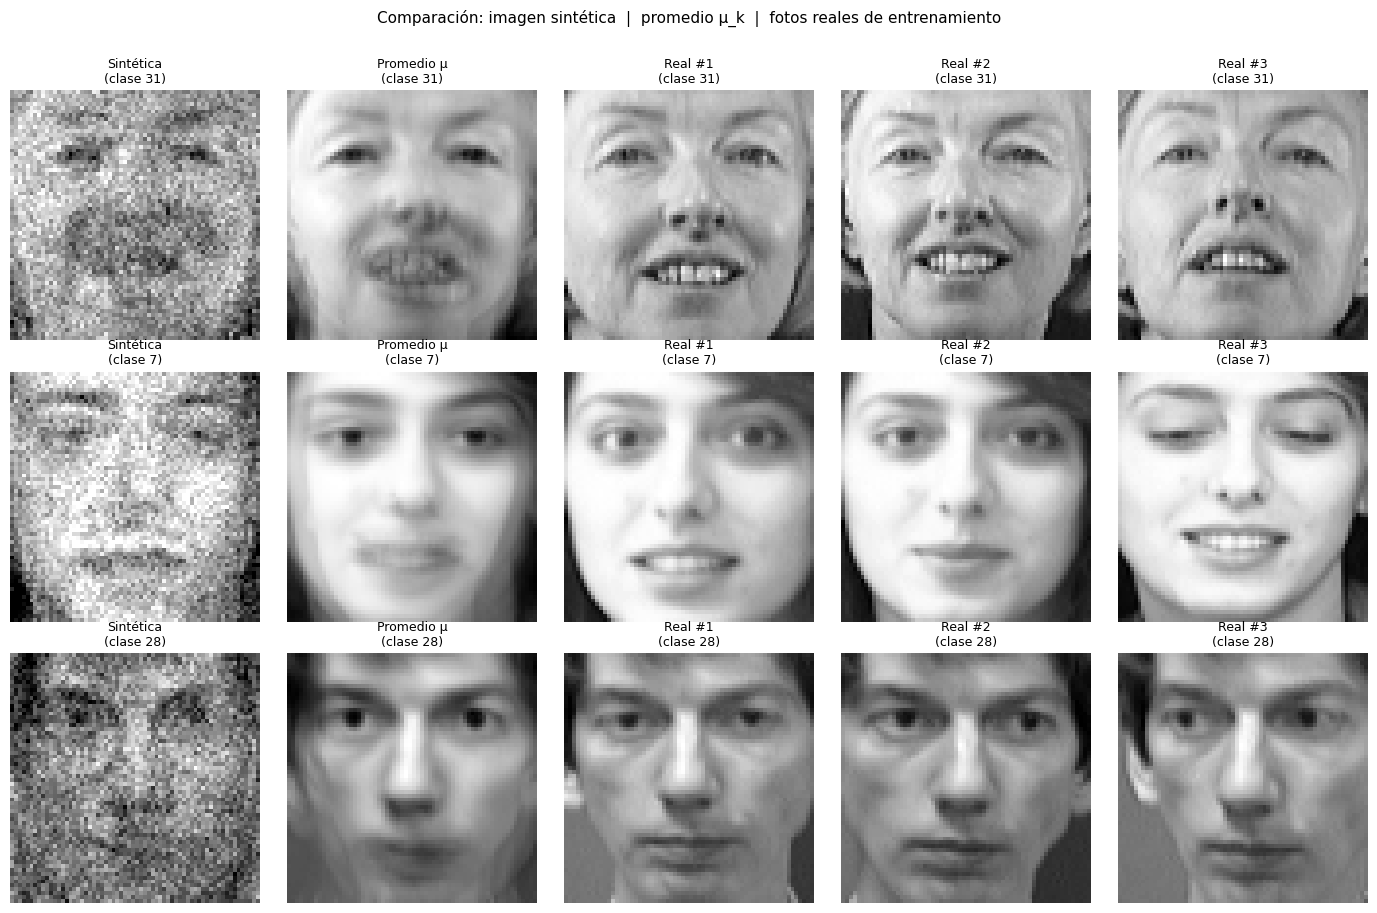

In [10]:
# --- PUNTO B.4: Simular 3 muestras sintéticas y compararlas con fotos reales ---
muestras, etiquetas = lda.sampling(n_samples=3)

fig, axes = plt.subplots(3, 5, figsize=(14, 9))

for fila, (img_sint, clase) in enumerate(zip(muestras, etiquetas)):

    # Columna 0: imagen sintética
    axes[fila, 0].imshow(np.clip(img_sint, 0, 1).reshape(64, 64), cmap="gray")
    axes[fila, 0].set_title(f"Sintética\n(clase {clase})", fontsize=9)
    axes[fila, 0].axis("off")

    # Separador visual: columna 1 = promedio μ_k
    idx_clase = np.where(lda.classes_ == clase)[0][0]
    axes[fila, 1].imshow(lda.means_[idx_clase].reshape(64, 64), cmap="gray")
    axes[fila, 1].set_title(f"Promedio μ\n(clase {clase})", fontsize=9)
    axes[fila, 1].axis("off")

    # Columnas 2-4: 3 fotos reales de entrenamiento de esa persona
    idx_reales = np.where(y_train == clase)[0][:3]
    for col, idx_r in enumerate(idx_reales, start=2):
        axes[fila, col].imshow(X_train[idx_r].reshape(64, 64), cmap="gray")
        axes[fila, col].set_title(f"Real #{col-1}\n(clase {clase})", fontsize=9)
        axes[fila, col].axis("off")

plt.suptitle(
    "Comparación: imagen sintética  |  promedio μ_k  |  fotos reales de entrenamiento",
    y=1.01, fontsize=11
)
plt.tight_layout()
plt.show()

Algo voy a poner sobre los tipajos estos.

## Ítem C: Quadratic Discriminant Analysis (QDA)


QDA puede pensarse como una extensión directa de LDA en la que se relaja un único supuesto:
en lugar de compartir una sola matriz de covarianza entre todas las personas, cada clase
cuenta con su propia covarianza $\hat{\Sigma}_k$.

La diferencia conceptual es simple, pero sus efectos son importantes. En LDA se estima una
única matriz de covarianza utilizando todas las imágenes de entrenamiento, lo que resulta
en una estimación relativamente estable incluso en un problema de alta dimensionalidad
(4096 píxeles por imagen). En cambio, en QDA se deben estimar 40 matrices distintas, cada
una a partir de solo 8 imágenes, en un espacio de miles de dimensiones. Esto implica que
los datos ocupan un subespacio extremadamente pequeño dentro del espacio original, por lo
que las covarianzas por clase quedan muy pobremente estimadas y son altamente sensibles al
ruido, volviendo al método numéricamente inestable.

La ventaja de QDA es su mayor flexibilidad: puede modelar que distintas personas presenten
patrones de variabilidad diferentes, dando lugar a fronteras de decisión cuadráticas.
Sin embargo, este beneficio tiene un costo importante, ya que con tan pocas muestras por
clase la regularización se vuelve crítica para que el algoritmo funcione correctamente.

### Punto 1

#### Selección intuitiva de λ antes de entrenar QDA

En QDA, la elección del parámetro de regularización $λ$ es crítica y debe hacerse antes de entrenar el modelo. Esto se debe a que, a diferencia de LDA, QDA estima una matriz de covarianza distinta para cada clase, y en este dataset cada persona cuenta con solo 8 imágenes de entrenamiento en un espacio de 4096 dimensiones. Como consecuencia, las matrices de covarianza estimadas son extremadamente singulares: con 8 muestras solo puede haber variación en como máximo 7 direcciones, mientras que el resto del espacio presenta varianza exactamente cero.

Este problema no es solamente numérico. En QDA, el término $log |Σ_k|$ aparece explícitamente en la función discriminante y no se cancela entre clases, como ocurre en LDA. Si una matriz de covarianza es singular o casi singular, su determinante es cero o muy pequeño, lo que hace que el log-determinante tome valores extremadamente negativos y domine la decisión. En ese caso, el clasificador deja de comparar similitud entre imágenes y pasa a decidir en base a diferencias puramente numéricas entre covarianzas mal estimadas.

Para evitar este colapso, se introduce la regularización (otra vez) $Σ_k + λ I$, que impone una varianza mínima igual a $λ$ en todas las direcciones del espacio, garantizando que el determinante sea finito.

La elección de este hiperparámetro, consiste en anclar $λ$ a la escala real de variación de los datos. Para ello, se calcula la varianza de cada píxel dentro de cada persona, es decir, la diagonal de la matriz de covarianza por clase. Estas varianzas reflejan cuánto cambian realmente los valores de los píxeles entre distintas imágenes de una misma persona y se pueden calcular de forma barata, sin construir matrices de $4096×4096$.

A partir de todas esas varianzas, se toma su mediana y se utiliza ese valor como $λ$. La mediana representa una variación típica del dataset y es robusta frente a píxeles con varianza extremadamente baja o alta. Si $λ$ fuera mucho menor que las varianzas observadas, la regularización sería insuficiente y el logarítmo del determinante seguiría siendo numéricamente inestable. Si fuera mucho mayor, se distorsionaría excesivamente la estructura real de los datos. Usar la mediana permite imponer una varianza mínima comparable a la variabilidad real observada, logrando un compromiso razonable entre estabilidad numérica y fidelidad estadística.


Distribución de varianzas por píxel dentro de cada clase:
  Percentil 10 : 0.00099
  Mediana      : 0.00574   ← λ propuesto
  Percentil 90 : 0.02231


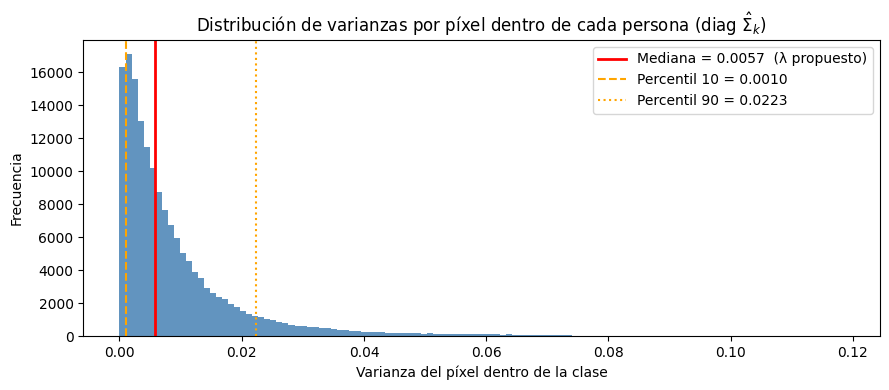


λ seleccionado para QDA: 0.00574


In [11]:
# --- Selección intuitiva de λ para QDA ---
# Calcular la varianza por píxel dentro de cada persona (diagonal de Σ_k)
# Es barato: no requiere armar la matriz 4096×4096, solo operar píxel a píxel
X_f64 = X_train.astype(np.float64)
all_pixel_vars = []

for k in np.unique(y_train):
    Xk = X_f64[y_train == k]
    var_k = Xk.var(axis=0, ddof=1)   # varianza insesgada por píxel, para la persona k
    all_pixel_vars.append(var_k)

all_pixel_vars = np.array(all_pixel_vars)   # (40, 4096)

# Estadísticas de referencia
p10     = np.percentile(all_pixel_vars, 10)
mediana = np.median(all_pixel_vars)
p90     = np.percentile(all_pixel_vars, 90)

print(f"Distribución de varianzas por píxel dentro de cada clase:")
print(f"  Percentil 10 : {p10:.5f}")
print(f"  Mediana      : {mediana:.5f}   ← λ propuesto")
print(f"  Percentil 90 : {p90:.5f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(all_pixel_vars.ravel(), bins=120, color="steelblue", edgecolor="none", alpha=0.85)
ax.axvline(mediana, color="red",    lw=2,   label=f"Mediana = {mediana:.4f}  (λ propuesto)")
ax.axvline(p10,     color="orange", lw=1.5, ls="--", label=f"Percentil 10 = {p10:.4f}")
ax.axvline(p90,     color="orange", lw=1.5, ls=":",  label=f"Percentil 90 = {p90:.4f}")
ax.set_xlabel("Varianza del píxel dentro de la clase")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de varianzas por píxel dentro de cada persona (diag $\\hat{\\Sigma}_k$)")
ax.legend()
plt.tight_layout()
plt.show()

lam_qda = mediana
print(f"\nλ seleccionado para QDA: {lam_qda:.5f}")


El histograma muestra cuántos de los $40 \times 4096 = 163.840$ valores de varianza caen en cada rango: si se sumaran las alturas de todas las barras, daría exactamente ese número. La gran mayoría se concentra cerca de cero porque las fotos de una misma persona genuinamente se parecen — el ojo siempre está en el mismo lugar, la estructura de la cara no cambia. Esto es una propiedad real del dataset, no una consecuencia de tener pocas muestras.

Cabe aclarar que el problema de las 4089 direcciones vacías en la matriz de covarianza (causado por tener solo 8 fotos) es un fenómeno distinto, estas, no aparecen en este histograma: el histograma muestra la diagonal de $\hat{\Sigma}_k$, es decir, la varianza de cada píxel individual.

La mediana (`0.0057`) es simplemente el valor del medio si ordenamos todos esos $163.840$ números de menor a mayor: la mitad tiene varianza menor a ese valor y la otra mitad mayor. A diferencia del promedio, no se ve afectada por los valores extremos de la cola derecha.

Ese valor se usa como $λ$ porque representa una escala típica de variabilidad real del dataset. Al regularizar con $\hat{\Sigma}_k + \lambda I$, se impone una varianza mínima de `0.0057` en todas las direcciones del espacio, lo que estabiliza numéricamente el modelo sin distorsionar la estructura real de los datos.

#### La función discriminante cuadrática

QDA parte exactamente igual que LDA: Bayes con gaussiana por clase. La fórmula completa, antes de simplificar nada, es:

$$\log P(k \mid x) \;\propto\; \log c_k \;-\; \frac{1}{2}\log|\tilde{\Sigma}_k| \;-\; \frac{1}{2}\underbrace{(x-\hat{\mu}_k)^T\tilde{\Sigma}_k^{-1}(x-\hat{\mu}_k)}_{\text{expandido: } x^T\tilde{\Sigma}_k^{-1}x \;-\; 2x^T\tilde{\Sigma}_k^{-1}\hat{\mu}_k \;+\; \hat{\mu}_k^T\tilde{\Sigma}_k^{-1}\hat{\mu}_k}$$

**LDA** usa esta misma fórmula, pero como todas las clases comparten la misma $\tilde{\Sigma}$ (sin subíndice $k$), dos términos son idénticos para toda clase $k$ y se cancelan al comparar:

- $-\frac{1}{2}\log|\tilde{\Sigma}|$ → constante global → se va
- $-\frac{1}{2}x^T\tilde{\Sigma}^{-1}x$ → constante global → se va

Lo que sobre es solo lo que varía entre clases, y queda la función lineal de LDA:

$$\tilde{\delta}_k^{\text{LDA}}(x) = x^T\tilde{\Sigma}^{-1}\hat{\mu}_k + \log c_k - \tfrac{1}{2}\hat{\mu}_k^T\tilde{\Sigma}^{-1}\hat{\mu}_k$$

**QDA** tiene una $\tilde{\Sigma}_k$ distinta por persona, así que esos dos términos son diferentes para cada clase y no se pueden cancelar. Por lo que se usa la fórmula completa:

$$\boxed{\tilde{\delta}_k(x) = \log c_k - \frac{1}{2}\log|\tilde{\Sigma}_k| - \frac{1}{2}(x-\hat{\mu}_k)^T\tilde{\Sigma}_k^{-1}(x-\hat{\mu}_k)}$$

En particular, el término expandido $x^T\tilde{\Sigma}_k^{-1}x$ depende de $k$ (cada clase tiene su propia inversa), lo que hace que la función discriminante sea cuadrática en $x$ — de ahí el nombre QDA.

---

**Dos problemas de implementación y cómo se resuelven**

Al querer implementar esto directo aparecen dos problemas concretos. Acá se explica la idea intuitiva de cada solución.



**Problema 1 — el determinante se vuelve cero en la computadora**

Para calcular $\log|\tilde{\Sigma}_k|$ la forma ingenua sería: primero calcular el determinante $|\tilde{\Sigma}_k|$, y después sacarle el logaritmo.

El problema es que el determinante de una matriz de $4096 \times 4096$ cuyos autovalores son casi todos iguales a $\lambda \approx 0.005$ es el producto de esos 4096 autovalores:

$$|\tilde{\Sigma}_k| \approx (0.005)^{4096} \approx 10^{-13000}$$

Ese número es tan pequeño que ningún float lo puede representar — la computadora sencillamente lo guarda como `0.0`. Y $\log(0) = -\infty$, lo que rompe todo.

La solución es usar `np.linalg.slogdet`, que nunca calcula el determinante en sí. En cambio, aprovecha que $\log(a \times b \times c \times \ldots) = \log a + \log b + \log c + \ldots$ y suma los logaritmos de los autovalores directamente, sin tener que multiplicarlos primero. Resultado igual, sin riesgo de underflow.

---

**Problema 2 — guardar 40 matrices de $4096 \times 4096$**

Para evaluar la función discriminante hay que calcular $(x - \hat{\mu}_k)^T \tilde{\Sigma}_k^{-1} (x - \hat{\mu}_k)$ para cada una de las 40 clases. La forma directa sería invertir las 40 matrices $\tilde{\Sigma}_k$ y guardarlas.

Pero cada matriz es de $4096 \times 4096$ valores `float64` ($8$ bytes cada uno). Una sola ocupa $4096^2 \times 8 \approx 134$ MB, y 40 de ellas son $\approx 5.4$ GB.

La observación clave es que $\hat{\Sigma}_k$ fue construida con solo 8 fotos. Una matriz construida con 8 puntos solo "tiene información en 8 direcciones" — las otras 4088 son artificialmente cero (antes de la regularización). En otras palabras, la matriz tiene rango 7, no rango 4096. Eso significa que su estructura real es mucho más compacta de lo que parece.

La identidad de Woodbury es una fórmula algebraica que permite explotar exactamente eso: en vez de invertir la matriz grande de $4096 \times 4096$, la reescribe en términos de una matriz de solo $8 \times 8$, que es trivialmente barata de invertir. Matemáticamente es la misma operación, pero reorganizada para aprovechar el rango bajo.

En el código, en lugar de guardar $\tilde{\Sigma}_k^{-1}$ (que ocupa 134 MB por clase), se guardan:
- $U_k$: los 8 datos centrados de esa persona, de tamaño $8 \times 4096$ (~0.25 MB)
- $R_k$: la matriz de corrección de tamaño $8 \times 8$ (~0.0005 MB)

Total por clase: ~0.25 MB en vez de 134 MB. Para las 40 clases, de 5.4 GB a ~10 MB.

#### Implementación de la clase QDA

Con todo lo anterior en claro, ya se puede construir el modelo.

In [12]:
class QDA:

    def __init__(self, lam=1e-2):
        """
        lam: factor de regularización λ para Σ̃_k = Σ_k + λI.
             Se usa la identidad de Woodbury para evitar almacenar 40 matrices de 4096×4096.
        """
        self.lam = lam

    def fit(self, X, y):
        X = X.astype(np.float64)
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        n, d = X.shape
        self.d_ = d

        self.priors_ = np.zeros(K)
        self.means_  = np.zeros((K, d))

        # Por Woodbury: almacenamos Uk (nk×d) y Rk = (I + Hk/λ)^{-1} (nk×nk)
        # en lugar de Σ̃_k^{-1} (d×d), lo que reduce la memoria de ~5 GB a unos pocos MB.
        self.Us_       = []   # (nk, d): datos centrados por clase
        self.Rs_       = []   # (nk, nk): (I + Hk/λ)^{-1}
        self.log_dets_ = np.zeros(K)

        for i, k in enumerate(self.classes_):
            Xk = X[y == k]
            nk = len(Xk)
            self.priors_[i] = nk / n
            mu_k = Xk.mean(axis=0)
            self.means_[i] = mu_k

            Uk = Xk - mu_k                                   # (nk, d): matriz centrada
            Hk = Uk @ Uk.T / (nk - 1)                       # (nk, nk): kernel de covarianza
            inner = np.eye(nk) + Hk / self.lam              # (nk, nk): I + Hk/λ

            self.Us_.append(Uk)
            self.Rs_.append(np.linalg.inv(inner))

            # log|Σ̃_k| = d·log(λ) + log|I_nk + Hk/λ|   (por teorema del determinante matricial)
            _, ld = np.linalg.slogdet(inner)
            self.log_dets_[i] = d * np.log(self.lam) + ld

        return self

    def _mahalanobis(self, X, i):
        """
        Distancia de Mahalanobis al cuadrado respecto a la clase i para cada fila de X.
        Por Woodbury: (x-μ)^T Σ̃_i^{-1} (x-μ) = (1/λ)||x-μ||² - (1/λ²(ni-1)) v^T Ri v
        donde v = Ui (x-μ)^T  →  diferencia proyectada sobre el subespacio de Ui.
        """
        diff  = X - self.means_[i]                          # (n_s, d)
        ni    = len(self.Us_[i])
        term1 = np.sum(diff ** 2, axis=1) / self.lam        # (n_s,)
        v     = diff @ self.Us_[i].T                        # (n_s, ni)
        term2 = np.sum((v @ self.Rs_[i]) * v, axis=1) / (self.lam ** 2 * (ni - 1))
        return term1 - term2

    def _discriminant(self, X):
        X = X.astype(np.float64)
        K = len(self.classes_)
        delta = np.zeros((X.shape[0], K))
        for i in range(K):
            mah = self._mahalanobis(X, i)
            delta[:, i] = (np.log(self.priors_[i])
                           - 0.5 * self.log_dets_[i]
                           - 0.5 * mah)
        return delta

    def predict_proba(self, X):
        """Predicción soft: probabilidad posterior de cada clase via softmax."""
        delta = self._discriminant(X)
        delta -= delta.max(axis=1, keepdims=True)
        exp_d = np.exp(delta)
        return exp_d / exp_d.sum(axis=1, keepdims=True)

    def predict(self, X):
        """Predicción hard: clase con mayor función discriminante."""
        delta = self._discriminant(X)
        return self.classes_[np.argmax(delta, axis=1)]

    def accuracy(self, X, y):
        """Proporción de predicciones correctas."""
        return np.mean(self.predict(X) == y)

    def sampling(self, n_samples=1):
        """
        Samplea x ~ N(μ_k, Σ̃_k) sin materializar Σ̃_k.
        Se usan los SVD de Uk para descomponer Σ̃_k en el subespacio de rango bajo y su complemento:
          - En el subespacio de Uk: autovalores λ + sj²/(nk-1)
          - En el complemento ortogonal: autovalor λ (uniforme)
        """
        rng = np.random.default_rng()
        d = self.d_
        samples, labels = [], []
        for _ in range(n_samples):
            k_idx = rng.choice(len(self.classes_), p=self.priors_)
            Uk = self.Us_[k_idx]
            nk = len(Uk)

            # SVD fino de Uk: Uk = P S Qt, donde Qt tiene forma (r, d)
            _, s, Qt = np.linalg.svd(Uk, full_matrices=False)
            r = len(s)
            eigvals = self.lam + s ** 2 / (nk - 1)   # autovalores de Σ̃_k en el subespacio

            # Componente dentro del subespacio de Uk: varianza eigvals[j] por dirección
            z_in  = Qt.T @ (np.sqrt(eigvals) * rng.standard_normal(r))

            # Componente fuera del subespacio: varianza λ en todas las direcciones,
            # proyectando fuera del subespacio para no doble-contar
            z_all = rng.standard_normal(d)
            z_out = np.sqrt(self.lam) * (z_all - Qt.T @ (Qt @ z_all))

            x = self.means_[k_idx] + z_in + z_out
            samples.append(x)
            labels.append(self.classes_[k_idx])
        return np.array(samples), np.array(labels)


Vale la pena aclarar que Woodbury y $\lambda$ no son alternativos sino complementarios: resuelven problemas distintos. La regularización es una necesidad estadística — sin ella, $\hat{\Sigma}_k$ tiene 4089 autovalores exactamente cero y su determinante es cero, lo que hace que $\log|\hat{\Sigma}_k|$ diverja. Woodbury, en cambio, es puramente un truco computacional: asume que $\tilde{\Sigma}_k$ ya es invertible y reorganiza el cálculo para evitar operar con matrices de $4096 \times 4096$. De hecho, la fórmula de Woodbury contiene un `/ self.lam` explícito, por lo que requiere $\lambda > 0$ para poder aplicarse. En otras palabras: primero $\lambda$ hace que la inversión exista, y después Woodbury la calcula eficientemente.

### Puntos 2 y 3

Se entrena QDA con el $\lambda$ seleccionado por el método propuesto y se evalúa el accuracy sobre los conjuntos de entrenamiento y testeo. Luego, al igual que en LDA, se verifica el comportamiento del modelo ante distintas semillas de split.


In [13]:
# --- PUNTO C.2: Entrenar QDA con λ propuesto ---
qda = QDA(lam=lam_qda)
qda.fit(X_train, y_train)
print("QDA entrenado.")

# --- PUNTO C.3: Accuracy de testeo ---
acc_test_qda  = qda.accuracy(X_test,  y_test)
acc_train_qda = qda.accuracy(X_train, y_train)
print(f"Accuracy train : {acc_train_qda:.2%}")
print(f"Accuracy test  : {acc_test_qda:.2%}")

print(f"\nComparación con LDA (λ=1e-2):")
print(f"  LDA  — train: {acc_train:.2%}  |  test: {acc_test:.2%}")
print(f"  QDA  — train: {acc_train_qda:.2%}  |  test: {acc_test_qda:.2%}")


QDA entrenado.
Accuracy train : 100.00%
Accuracy test  : 98.75%

Comparación con LDA (λ=1e-2):
  LDA  — train: 100.00%  |  test: 100.00%
  QDA  — train: 100.00%  |  test: 98.75%


In [14]:
# --- Verificación: distintas semillas — QDA (λ = lam_qda) vs LDA (λ = 1e-2) ---
seeds = [1, 2, 3, 4]

print(f"{'seed':>5}  {'LDA train':>10}  {'LDA test':>9}  {'QDA train':>10}  {'QDA test':>9}")
print("-" * 52)
for s in seeds:
    rng_s = np.random.default_rng(seed=s)
    tr_idx, te_idx = [], []
    for clase in np.unique(y):
        idx_c = np.where(y == clase)[0]
        eleg  = rng_s.choice(idx_c, size=2, replace=False)
        te_idx.extend(eleg)
        tr_idx.extend([i for i in idx_c if i not in eleg])
    Xtr, ytr = X[np.array(tr_idx)], y[np.array(tr_idx)]
    Xte, yte = X[np.array(te_idx)],  y[np.array(te_idx)]

    lda_s = LDA(lam=1e-2).fit(Xtr, ytr)
    qda_s = QDA(lam=lam_qda).fit(Xtr, ytr)
    print(f"{s:>5}  {lda_s.accuracy(Xtr,ytr):>10.1%}  {lda_s.accuracy(Xte,yte):>9.1%}"
          f"  {qda_s.accuracy(Xtr,ytr):>10.1%}  {qda_s.accuracy(Xte,yte):>9.1%}")

 seed   LDA train   LDA test   QDA train   QDA test
----------------------------------------------------
    1      100.0%      98.8%      100.0%      98.8%
    2      100.0%      97.5%      100.0%      96.2%
    3      100.0%      98.8%      100.0%      95.0%
    4      100.0%      96.2%      100.0%      92.5%


#### Comparación con LDA: ¿cuándo conviene cada modelo?

Los resultados muestran que **LDA supera a QDA** en este dataset, lo cual es esperable y tiene una explicación directa en el tradeoff bias-varianza.

LDA estima una única covarianza $\hat{\Sigma}$ usando las 320 imágenes de entrenamiento juntas, lo que le da suficiente información para estimarla con razonnable solidez estadística. QDA, en cambio, estima 40 covarianzas individuales $\hat{\Sigma}_k$ con solo 8 muestras cada una. Con tan pocas muestras, cada $\hat{\Sigma}_k$ tiene rango 7 en un espacio de 4096 dimensiones: la mayor parte de su estructura refleja ruido de muestreo, no propiedades reales de la persona. La flexibilidad adicional de QDA (fronteras cuadráticas, covarianza propia por clase) en este contexto solo amplifica ese error de estimación sin aportar ganancia discriminativa.

Cabe señalar que incrementar $\lambda$ tampoco resolvería esta limitación. Si $\lambda$ fuera lo suficientemente grande, todas las covarianzas individuales colapsarían a $\lambda I$ y QDA comenzaría a comportarse como LDA — y en ese caso aparente "mejora", pero únicamente porque dejó de ser QDA en la práctica. El problema de fondo es el tamaño muestral, no la elección del hiperparámetro.

La tabla de distintas semillas confirma esta mayor inestabilidad de QDA: el accuracy en test oscila entre 92.5% y 98.8%, frente al 97.5%–100% de LDA. Ambos modelos encuentran su mayor dificultad con la semilla 4, lo que sugiere que ese split en particular asigna al conjunto de test imágenes menos representativas para varias personas.

Finalmente, vale la pena preguntarse en qué condiciones QDA superaría a LDA. La respuesta es doble: se necesita que las covarianzas realmente difieran entre clases *y* que haya suficientes muestras para estimarlas bien. Un dataset con grupos de variabilidad estructuralmente distinta —por ejemplo, imágenes de niños, adultos y personas mayores, cuya forma y textura facial varían de manera cualitativamente diferente— cumpliría la primera condición. Olivetti, al ser un dataset de adultos en condiciones controladas con iluminación y pose uniformes, se ajusta bien al supuesto de LDA: la variabilidad típica es similar entre personas, y una sola covarianza pooled la captura adecuadamente.

#### Punto 4: Muestras sintéticas de QDA vs LDA

Al igual que LDA, QDA es un modelo generativo. La diferencia es que ahora cada persona tiene su propia distribución $\mathcal{N}(\hat{\mu}_k, \tilde{\Sigma}_k)$, por lo que la variación agregada a cada muestra es específica de esa clase. Para evaluar si esta diferencia se traduce en imágenes más realistas, se comparan directamente muestras sintéticas de ambos modelos para las mismas personas, junto con el promedio $\hat{\mu}_k$ y fotos reales de entrenamiento.

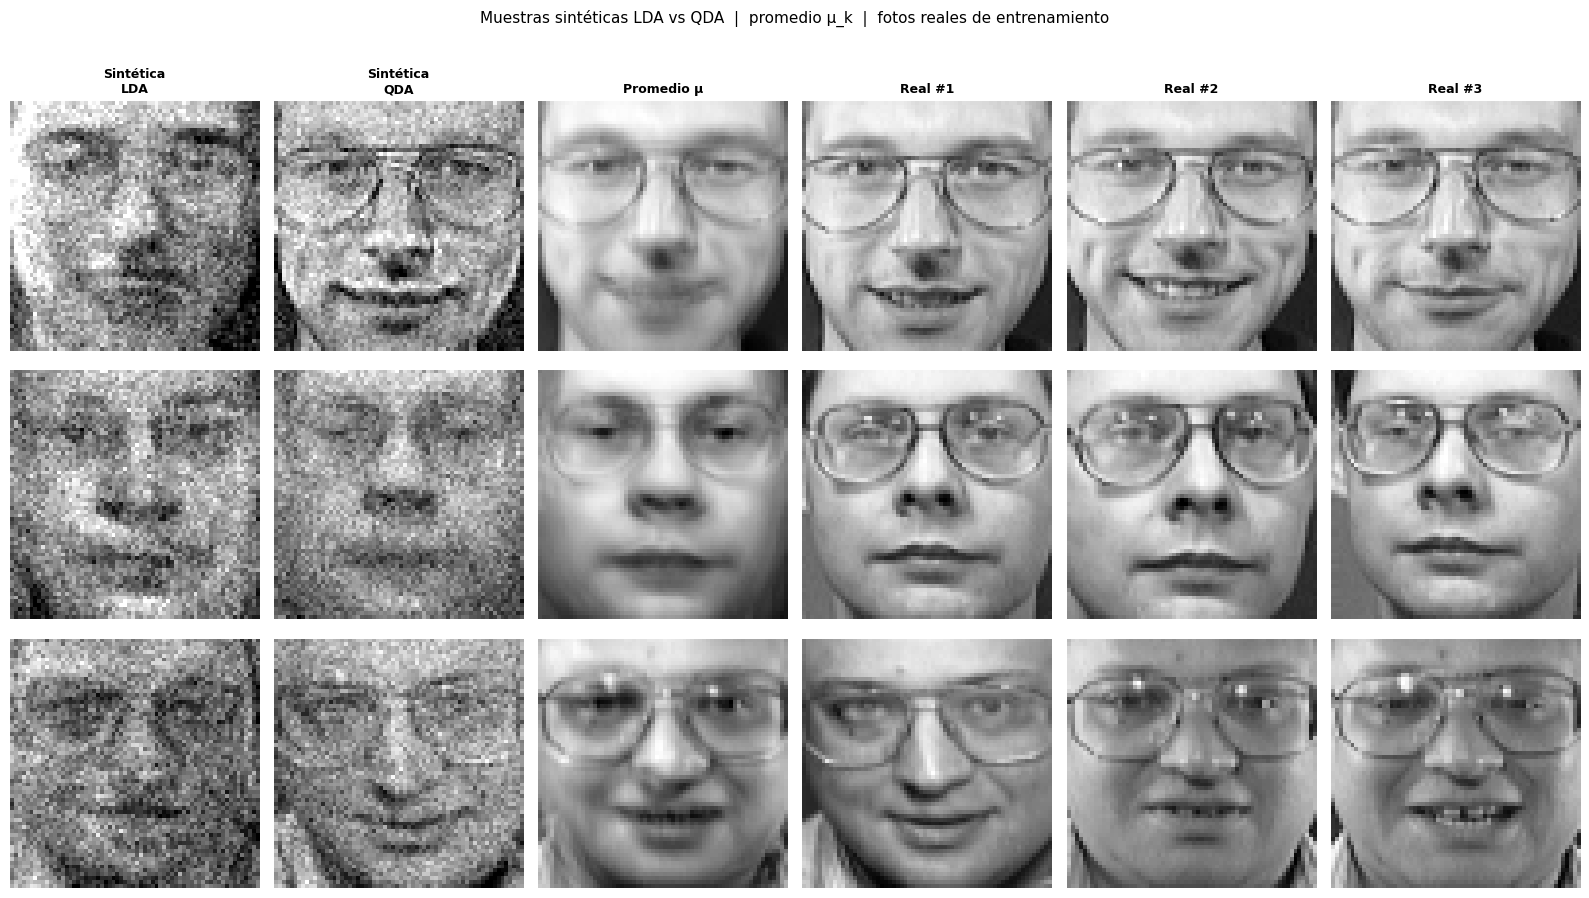

In [15]:
# --- PUNTO C.4: Muestras sintéticas de QDA vs LDA comparadas con fotos reales ---
# Se fija la clase para que ambos modelos sampleen de la misma persona
rng_sample = np.random.default_rng(seed=42)
clases_muestra = rng_sample.choice(len(qda.classes_), size=3, replace=False)

fig, axes = plt.subplots(3, 6, figsize=(16, 9))

col_titles = ["Sintética\nLDA", "Sintética\nQDA", "Promedio μ", "Real #1", "Real #2", "Real #3"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=9, fontweight="bold")

for fila, k_idx in enumerate(clases_muestra):
    clase = qda.classes_[k_idx]

    # Samplear una muestra de LDA para esta clase
    L_lda = np.linalg.cholesky(lda.Sigma_reg_)
    z = np.random.default_rng().standard_normal(lda.means_.shape[1])
    img_lda = lda.means_[k_idx] + L_lda @ z

    # Samplear una muestra de QDA para esta clase
    Uk = qda.Us_[k_idx]
    nk = len(Uk)
    _, s, Qt = np.linalg.svd(Uk, full_matrices=False)
    eigvals  = qda.lam + s ** 2 / (nk - 1)
    rng2     = np.random.default_rng()
    z_in     = Qt.T @ (np.sqrt(eigvals) * rng2.standard_normal(len(s)))
    z_all    = rng2.standard_normal(qda.d_)
    z_out    = np.sqrt(qda.lam) * (z_all - Qt.T @ (Qt @ z_all))
    img_qda  = qda.means_[k_idx] + z_in + z_out

    imgs = [img_lda, img_qda, qda.means_[k_idx]]
    for col, img in enumerate(imgs):
        axes[fila, col].imshow(np.clip(img, 0, 1).reshape(64, 64), cmap="gray")
        axes[fila, col].set_ylabel(f"Clase {clase}", fontsize=8)
        axes[fila, col].axis("off")

    # Columnas 3-5: fotos reales de entrenamiento
    idx_reales = np.where(y_train == clase)[0][:3]
    for col, idx_r in enumerate(idx_reales, start=3):
        axes[fila, col].imshow(X_train[idx_r].reshape(64, 64), cmap="gray")
        axes[fila, col].axis("off")

plt.suptitle(
    "Muestras sintéticas LDA vs QDA  |  promedio μ_k  |  fotos reales de entrenamiento",
    y=1.01, fontsize=11
)
plt.tight_layout()
plt.show()

Aunque LDA supera a QDA en accuracy de clasificación, la situación se invierte cuando se evalúa la calidad generativa. Las muestras sintéticas de QDA preservan rasgos específicos de cada persona —como la presencia de anteojos o la forma particular del rostro— mientras que las de LDA tienden a producir imágenes más "genéricas", con la textura de variación promedio de todas las personas mezclada.

La razón es directa: generación y clasificación requieren cosas distintas del modelo.

- **Para clasificar**, alcanza con que las fronteras de decisión estén bien ubicadas. LDA logra esto con una covarianza pooled bien estimada, porque dispone de 320 muestras para aprenderla. QDA, con solo 8 muestras por persona, aprende covarianzas ruidosas que distorsionan esas fronteras.

- **Para generar**, lo que importa es samplear de la distribución correcta de cada clase. Aquí QDA tiene ventaja: al usar $\tilde{\Sigma}_k$ individual, la variación que agrega al promedio $\hat{\mu}_k$ refleja (aunque sea ruidosamente) la variabilidad real de *esa* persona. LDA, al usar $\hat{\Sigma}$ pooled, agrega variación a nivel de población — es la mezcla de cómo varían *todas* las personas — lo cual resulta en muestras visualmente menos coherentes con la identidad de la clase.

En términos del tradeoff bias-varianza: los parámetros extra de QDA son perjudiciales para la discriminación (alta varianza en la frontera), pero beneficiosos para la generación (mayor fidelidad distribucional por clase). Esto refleja que QDA es un mejor modelo generativo incluso cuando es un peor clasificador: modela la estructura correcta, aunque con mayor incertidumbre de estimación.

#### Curiosidad: ¿QDA entrena más rápido que LDA gracias a Woodbury?

Una consecuencia del truco de Woodbury es que QDA resulta más rápido de entrenar que LDA en este dataset.

LDA requiere construir e invertir una única matriz de covarianza de $4096 \times 4096$, una operación de costo $O(d^3)$ con $d = 4096$. QDA, en cambio, nunca materializa matrices de esa dimensión: gracias a Woodbury, el entrenamiento se reduce a invertir 40 matrices de $8 \times 8$ (una por persona), lo que es órdenes de magnitud más barato.

La situación se invierte en la predicción. LDA precomputa durante el entrenamiento la matriz $W = \hat{\boldsymbol{\mu}} \cdot \tilde{\Sigma}^{-1}$ y clasifica una nueva imagen con un único producto matricial $O(K \cdot d)$. Mientras que QDA no puede hacer eso —cada clase tiene su propia inversa— y debe recalcular la distancia de Mahalanobis vía Woodbury para cada consulta, lo que introduce un factor adicional de orden $n_k$ por clase.

En síntesis, el truco de Woodbury traslada el costo computacional del entrenamiento hacia la predicción. Para aplicaciones donde se entrena una vez y se clasifica con frecuencia, LDA sigue siendo la opción más eficiente; sin embargo, en la fase de ajuste del modelo, QDA resulta considerablemente más liviano.

## Ítem D: K-Nearest Neighbors (KNN)

KNN es un clasificador no paramétrico y *lazy*: no aprende un modelo durante el entrenamiento ni estima parámetros. Simplemente almacena todas las imágenes de entrenamiento y, al clasificar una imagen nueva, asigna la clase según las imágenes de entrenamiento más parecidas.

#### ¿Cómo funciona?

Dada una imagen nueva $x$, KNN calcula su distancia euclidiana a todas las imágenes de entrenamiento:

$$d(x, x_i) = \|x - x_i\|_2$$

No hay nada que "aprender": el entrenamiento consiste únicamente en memorizar los datos. El costo se paga en la predicción: clasificar una imagen requiere compararla contra las 320 de entrenamiento, cada una de 4096 dimensiones. El código usa el truco $\|x - x_i\|^2 = \|x\|^2 + \|x_i\|^2 - 2\,x \cdot x_i$ para vectorizar todas las distancias en un único producto matricial, en lugar de iterar una por una.

#### $\hat{P}(Y = k \mid x)$

Una vez identificados los $K$ vecinos más cercanos, se mira a qué persona pertenece cada uno. Si de los 5 vecinos más cercanos, 3 son de la persona 7 y 2 de la persona 12, entonces:

$$\hat{P}(Y = 7 \mid x) = \tfrac{3}{5}, \quad \hat{P}(Y = 12 \mid x) = \tfrac{2}{5}, \quad \hat{P}(Y = k \mid x) = 0 \text{ para el resto}$$

Formalmente, es la fracción de vecinos de cada clase:

$$\hat{P}(Y = k \mid x) = \frac{1}{K} \sum_{i \in \mathcal{N}_K(x)} \mathbf{1}[y_i = k]$$

`predict` simplemente devuelve la clase con mayor fracción (la ganadora de la votación).

#### El hiperparámetro K

$K$ no se calcula, se elige empíricamente. No existe una fórmula que dé el valor óptimo — depende del dataset, del ruido, de cuántas muestras hay por clase. Lo que sí se puede hacer es evaluar el accuracy de test para distintos valores de $K$ y quedarse con el mejor.

En cuanto al tradeoff:

- **$K = 1$**: asigna la etiqueta del vecino más cercano. Fronteras irregulares. En entrenamiento el accuracy es siempre 100% (cada punto es su propio vecino más cercano), pero puede no generalizar bien.
- **$K$ grande**: suaviza las fronteras al promediar más votos, pero si $K$ es demasiado grande se mezclan clases y el accuracy cae.

#### ¿Qué pasa con K par y empate?

Con $K$ par puede ocurrir que dos o más clases terminen con la misma cantidad de votos. Por ejemplo, con $K = 4$: dos vecinos son de la persona 3 y dos de la persona 17 — ¿a quién se le asigna la imagen?

Existen dos estrategias habituales para resolverlo:

- **Reducir $K$ hasta romper el empate**: se baja de $K = 4$ a $K = 3$, y así. En algún punto el número impar de vecinos fuerza un ganador.

- **Voto ponderado por distancia**: en lugar de contar cada vecino con peso 1, se le da más importancia a los que están más cerca. El peso de cada vecino es $w_i = 1/d_i$: si la persona 3 está a distancia 0.1 y la persona 17 a distancia 0.9, los votos de la persona 3 suman $1/0.1 = 10$ mientras que los de la persona 17 suman $1/0.9 \approx 1.1$. El empate exacto se vuelve prácticamente imposible porque requeriría que ambas clases tengan la misma distancia total acumulada, lo cual es un evento de probabilidad cero en datos continuos.

En la implementación de este TP se usa `argmax` directamente sobre las proporciones. En caso de empate exacto, `argmax` devuelve la primera clase empatada (la de menor índice) — arbitrario pero determinístico. Con 40 clases y valores de $K$ razonables, la probabilidad de que esto ocurra es despreciable.

### Punto 1

In [16]:
# --- PUNTO D.1: Implementación de KNN ---

class KNN:
    # Inicializar atributos y declarar hiperparámetros
    def __init__(self, k=1):
        self.k = k

    # Etapa de entrenamiento: solo guarda los datos
    def fit(self, X, y):
        self.X_train  = X
        self.y_train  = y
        self.classes_ = np.unique(y)
        return self

    # Etapa de testeo soft: fracción de vecinos de cada clase
    def predict_proba(self, X):
        # Distancias euclidianas al cuadrado: ||x - xi||^2 = ||x||^2 + ||xi||^2 - 2*x·xi
        dist2  = (
            np.sum(X**2,            axis=1, keepdims=True)
            + np.sum(self.X_train**2, axis=1)
            - 2 * (X @ self.X_train.T)
        )  # shape: (n_test, n_train)

        idx_nn = np.argsort(dist2, axis=1)[:, :self.k]   # (n_test, k) índices más cercanos
        labels = self.y_train[idx_nn]                     # (n_test, k) etiquetas de vecinos

        proba = np.zeros((len(X), len(self.classes_)))
        for j, clase in enumerate(self.classes_):
            proba[:, j] = np.sum(labels == clase, axis=1) / self.k
        return proba

    # Etapa de testeo hard: clase más votada
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

    # Cómputo del accuracy
    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

### Punto 2

Se grafica el accuracy de testeo (y de entrenamiento, para referencia) en función de $K$, barriendo valores de 1 a 30. El punto donde la curva de test alcanza su máximo es el $K$ óptimo para este dataset.

Vale notar que la curva de entrenamiento en $K=1$ siempre da 100%, pero no porque el modelo sea perfecto — sino porque es un efecto trivial: al clasificar una imagen de entrenamiento, el algoritmo busca su vecino más cercano dentro del mismo conjunto de entrenamiento, y esa imagen se encuentra a sí misma a distancia 0. Le asigna su propia etiqueta y acierta siempre. Es como preguntarle a alguien quién es y que se mire en un espejo. Por eso el accuracy de entrenamiento con $K=1$ no dice nada útil sobre la calidad del modelo.

K óptimo (máximo accuracy de test): K = 1  →  96.2%


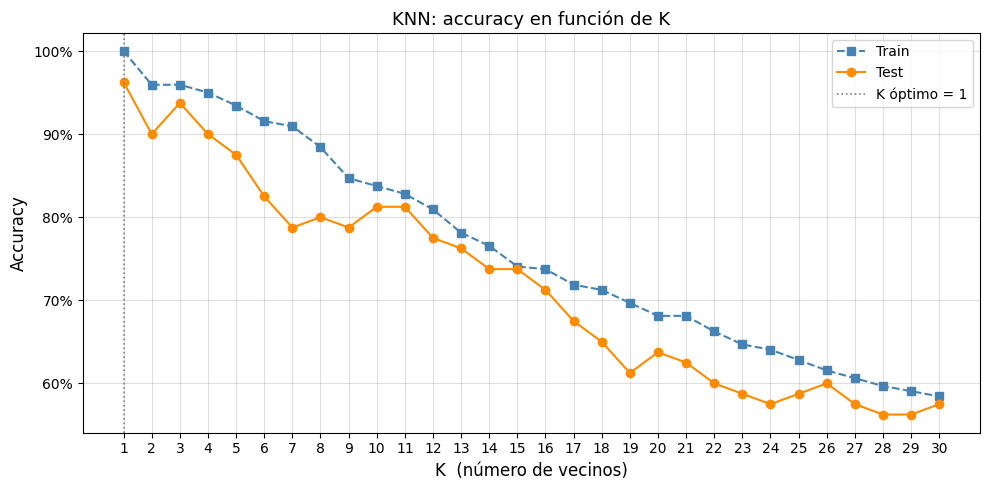

In [17]:
# --- PUNTO D.2: Accuracy de testeo en función de K ---
ks          = np.arange(1, 31)
acc_train   = []
acc_test    = []

for k in ks:
    knn = KNN(k=k).fit(X_train, y_train)
    acc_train.append(knn.accuracy(X_train, y_train))
    acc_test.append(knn.accuracy(X_test,  y_test))

k_opt = ks[np.argmax(acc_test)]
print(f"K óptimo (máximo accuracy de test): K = {k_opt}  →  {max(acc_test):.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks, acc_train, marker="s", linestyle="--", color="steelblue",  label="Train")
ax.plot(ks, acc_test,  marker="o", linestyle="-",  color="darkorange", label="Test")
ax.axvline(k_opt, color="gray", linestyle=":", linewidth=1.2, label=f"K óptimo = {k_opt}")
ax.set_xlabel("K  (número de vecinos)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("KNN: accuracy en función de K", fontsize=13)
ax.set_xticks(ks)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

El gráfico muestra una tendencia muy clara: tanto el accuracy de train como el de test caen de forma sostenida a medida que crece $K$, sin ninguna recuperación. El $K$ óptimo resulta ser $K=1$, con ~96% de accuracy en test.

La explicación está en las propiedades del dataset:

- **Las 40 personas son muy distintas entre sí**: la estructura facial de cada individuo (forma de la cara, presencia de anteojos, tipo de pelo) crea clusters bien separados en el espacio de píxeles. El vecino más cercano de una imagen casi siempre pertenece a la misma persona.
  
- **Las 8 imágenes de cada persona son muy parecidas entre sí**: al aumentar $K$, los vecinos más lejanos empiezan a pertenecer a otras personas. En un dataset con clases más compactas y separadas, usar más vecinos suma ruido en lugar de señal.

- **El problema en el que $K$ grande ayuda**: cuando hay mucho ruido dentro de cada clase y las fronteras entre clases son difusas. Ahí promediar más vecinos suaviza el ruido. Olivetti no tiene ese problema — las fotos de una misma persona son muy homogéneas.

En términos del tradeoff bias-varianza: con $K=1$ el modelo tiene alta varianza pero muy poco sesgo, y los datos son suficientemente "limpios" como para que alta varianza no sea un problema. Al escalar $K$, el sesgo crece más rápido de lo que cae la varianza — de ahí la caída monotónica.



Para comparar KNN con LDA y QDA en los mismos splits, se evalúa KNN con $K=1$ sobre las semillas 1 a 4.

In [20]:
# --- Verificación: distintas semillas — KNN (K=1) ---
seeds = [1, 2, 3, 4]

print("KNN:")
print(f"{'seed':>5}  {'KNN train':>10}  {'KNN test':>9}")
print("-" * 29)
for s in seeds:
    rng_s = np.random.default_rng(seed=s)
    tr_idx, te_idx = [], []
    for clase in np.unique(y):
        idx_c = np.where(y == clase)[0]
        eleg  = rng_s.choice(idx_c, size=2, replace=False)
        te_idx.extend(eleg)
        tr_idx.extend([i for i in idx_c if i not in eleg])
    Xtr, ytr = X[np.array(tr_idx)], y[np.array(tr_idx)]
    Xte, yte = X[np.array(te_idx)],  y[np.array(te_idx)]

    knn_s = KNN(k=1).fit(Xtr, ytr)
    print(f"{s:>5}  {knn_s.accuracy(Xtr, ytr):>10.1%}  {knn_s.accuracy(Xte, yte):>9.1%}")

KNN:
 seed   KNN train   KNN test
-----------------------------
    1      100.0%      97.5%
    2      100.0%      91.2%
    3      100.0%      92.5%
    4      100.0%      91.2%


A continuación se resumen los resultados de los tres modelos sobre las cinco semillas evaluadas (accuracy en test):

| Semilla | LDA (λ = 1e-2) | QDA (λ = λ*) | KNN (K = 1) |
|:-------:|:--------------:|:------------:|:-----------:|
| 0       | 100.0%         | 98.8%        | 96.2%       |
| 1       | 98.8%          | 98.8%        | 97.5%       |
| 2       | 97.5%          | 96.2%        | 91.2%       |
| 3       | 98.8%          | 95.0%        | 92.5%       |
| 4       | 96.2%          | 92.5%        | 91.2%       |


## Conclusiones

Los tres algoritmos implementados logran un desempeño muy alto en Olivetti Faces, lo cual no es sorprendente: el dataset fue construido en condiciones controladas y las diferencias entre personas son grandes y sistemáticas. Aun así, los resultados permiten sacar conclusiones concretas sobre cómo afecta la estructura del problema a cada modelo.

**LDA** fue el mejor clasificador, alcanzando hasta 100% de accuracy en test con `seed=0` y manteniéndose por encima del 97% en distintas semillas. Su ventaja es que explota la estructura de varianza del dataset: al ponderar los píxeles según cuánto varían, le da más peso a la estructura ósea de la cara y menos al fondo o a la iluminación — exactamente las señales discriminantes correctas.

**QDA** quedó segundo, con mayor variabilidad entre semillas (92–99%). Tiene más libertad que LDA al estimar una covarianza por persona, pero con solo 8 imágenes en 4096 dimensiones esa libertad se convierte en ruido. Sin embargo, mostró ser el mejor modelo generativo: al samplear con la covarianza individual de cada persona, las imágenes sintéticas preservan rasgos propios de cada individuo que LDA no captura.

**KNN** con $K=1$ resultó competitivo (~96%), lo que refleja que las clases están bien separadas en el espacio de píxeles. La caída monótona del accuracy al aumentar $K$ confirma que el dataset no tiene ruido intra-clase que necesite ser suavizado. Su limitación respecto a LDA es no ponderar píxeles: trata el fondo igual que la forma de la cara.

En síntesis, LDA es el algoritmo más adecuado para este problema específico: sus supuestos (covarianza compartida, variabilidad homogénea entre clases) se ajustan bien a cómo fue construido Olivetti. QDA y KNN son alternativas válidas pero quedan ligeramente por debajo por razones bien identificadas — escasez de datos para QDA y ausencia de ponderación de features para KNN.